In [1]:
# # Machine Learning Capstone Project
# ## Classification Track — Review 1

# ### Dataset: Steel Plates Faults

# **Objective:**

# The objective of this project is to develop machine learning
# classification models to identify the type of fault present in
# steel plates based on measured features.

# ### Review 1 Scope

# The following Classification Part-A algorithms are implemented:

# 1. Logistic Regression
# 2. K-Nearest Neighbors (KNN)
# 3. Gaussian Naive Bayes
# 4. Decision Tree Classifier
# 5. Support Vector Classifier (SVC)

# ### Evaluation Metrics

# - Accuracy
# - Weighted F1-score
# - Confusion Matrix

In [2]:
# ==============================
# IMPORT REQUIRED LIBRARIES
# ==============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

# Plot settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ==============================
# LOAD DATASET
# ==============================

df = pd.read_csv("Faults_classification.csv")

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (1941, 28)


In [4]:
# First 5 rows
df.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,target
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,Pastry
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,Pastry
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,Pastry
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,Pastry
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,Pastry


In [5]:
# Last 5 rows
df.tail()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,target
1936,249,277,325780,325796,273,54,22,35033,119,141,...,0.5185,0.7273,0.0,2.4362,1.4472,1.2041,-0.4286,0.0026,0.7254,Other_Faults
1937,144,175,340581,340598,287,44,24,34599,112,133,...,0.7046,0.7083,0.0,2.4579,1.4914,1.2305,-0.4516,-0.0582,0.8173,Other_Faults
1938,145,174,386779,386794,292,40,22,37572,120,140,...,0.7250,0.6818,0.0,2.4654,1.4624,1.1761,-0.4828,0.0052,0.7079,Other_Faults
1939,137,170,422497,422528,419,97,47,52715,117,140,...,0.3402,0.6596,0.0,2.6222,1.5185,1.4914,-0.0606,-0.0171,0.9919,Other_Faults
1940,1261,1281,87951,87967,103,26,22,11682,101,133,...,0.7692,0.7273,0.0,2.0128,1.3010,1.2041,-0.2000,-0.1139,0.5296,Other_Faults


In [6]:
# Dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1941
Number of columns: 28


In [7]:
# Column names
df.columns.tolist()

['X_Minimum',
 'X_Maximum',
 'Y_Minimum',
 'Y_Maximum',
 'Pixels_Areas',
 'X_Perimeter',
 'Y_Perimeter',
 'Sum_of_Luminosity',
 'Minimum_of_Luminosity',
 'Maximum_of_Luminosity',
 'Length_of_Conveyer',
 'TypeOfSteel_A300',
 'TypeOfSteel_A400',
 'Steel_Plate_Thickness',
 'Edges_Index',
 'Empty_Index',
 'Square_Index',
 'Outside_X_Index',
 'Edges_X_Index',
 'Edges_Y_Index',
 'Outside_Global_Index',
 'LogOfAreas',
 'Log_X_Index',
 'Log_Y_Index',
 'Orientation_Index',
 'Luminosity_Index',
 'SigmoidOfAreas',
 'target']

In [8]:
# ==============================
# DATASET INFORMATION
# ==============================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empt

In [9]:
# ==============================
# DATA TYPES
# ==============================

df.dtypes

X_Minimum                  int64
X_Maximum                  int64
Y_Minimum                  int64
Y_Maximum                  int64
Pixels_Areas               int64
X_Perimeter                int64
Y_Perimeter                int64
Sum_of_Luminosity          int64
Minimum_of_Luminosity      int64
Maximum_of_Luminosity      int64
Length_of_Conveyer         int64
TypeOfSteel_A300           int64
TypeOfSteel_A400           int64
Steel_Plate_Thickness      int64
Edges_Index              float64
Empty_Index              float64
Square_Index             float64
Outside_X_Index          float64
Edges_X_Index            float64
Edges_Y_Index            float64
Outside_Global_Index     float64
LogOfAreas               float64
Log_X_Index              float64
Log_Y_Index              float64
Orientation_Index        float64
Luminosity_Index         float64
SigmoidOfAreas           float64
target                    object
dtype: object

In [10]:
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:
X_Minimum                0
X_Maximum                0
Y_Minimum                0
Y_Maximum                0
Pixels_Areas             0
X_Perimeter              0
Y_Perimeter              0
Sum_of_Luminosity        0
Minimum_of_Luminosity    0
Maximum_of_Luminosity    0
Length_of_Conveyer       0
TypeOfSteel_A300         0
TypeOfSteel_A400         0
Steel_Plate_Thickness    0
Edges_Index              0
Empty_Index              0
Square_Index             0
Outside_X_Index          0
Edges_X_Index            0
Edges_Y_Index            0
Outside_Global_Index     0
LogOfAreas               0
Log_X_Index              0
Log_Y_Index              0
Orientation_Index        0
Luminosity_Index         0
SigmoidOfAreas           0
target                   0
dtype: int64

Total missing values: 0


In [11]:
# ==============================
# DUPLICATES
# ==============================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
# ==============================
# STATISTICAL SUMMARY
# ==============================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
X_Minimum,1941.0,5.711360e+02,5.206907e+02,0.0000,51.0000,4.350000e+02,1.053000e+03,1.705000e+03
X_Maximum,1941.0,6.179645e+02,4.976274e+02,4.0000,192.0000,4.670000e+02,1.072000e+03,1.713000e+03
Y_Minimum,1941.0,1.650685e+06,1.774578e+06,6712.0000,471253.0000,1.204128e+06,2.183073e+06,1.298766e+07
Y_Maximum,1941.0,1.650739e+06,1.774590e+06,6724.0000,471281.0000,1.204136e+06,2.183084e+06,1.298769e+07
Pixels_Areas,1941.0,1.893878e+03,5.168460e+03,2.0000,84.0000,1.740000e+02,8.220000e+02,1.526550e+05
X_Perimeter,1941.0,1.118552e+02,3.012092e+02,2.0000,15.0000,2.600000e+01,8.400000e+01,1.044900e+04
Y_Perimeter,1941.0,8.296600e+01,4.264829e+02,1.0000,13.0000,2.500000e+01,8.300000e+01,1.815200e+04
Sum_of_Luminosity,1941.0,2.063121e+05,5.122936e+05,250.0000,9522.0000,1.920200e+04,8.301100e+04,1.159141e+07
Minimum_of_Luminosity,1941.0,8.454869e+01,3.213428e+01,0.0000,63.0000,9.000000e+01,1.060000e+02,2.030000e+02
Maximum_of_Luminosity,1941.0,1.301937e+02,1.869099e+01,37.0000,124.0000,1.270000e+02,1.400000e+02,2.530000e+02


In [13]:
# ==============================
# TARGET CLASS DISTRIBUTION
# ==============================

class_counts = df["target"].value_counts()

print(class_counts)

target
Other_Faults    673
Bumps           402
K_Scatch        391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
Name: count, dtype: int64


In [14]:
# Percentage distribution

class_percentage = (
    df["target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(class_percentage)

target
Other_Faults    34.67
Bumps           20.71
K_Scatch        20.14
Z_Scratch        9.79
Pastry           8.14
Stains           3.71
Dirtiness        2.83
Name: proportion, dtype: float64


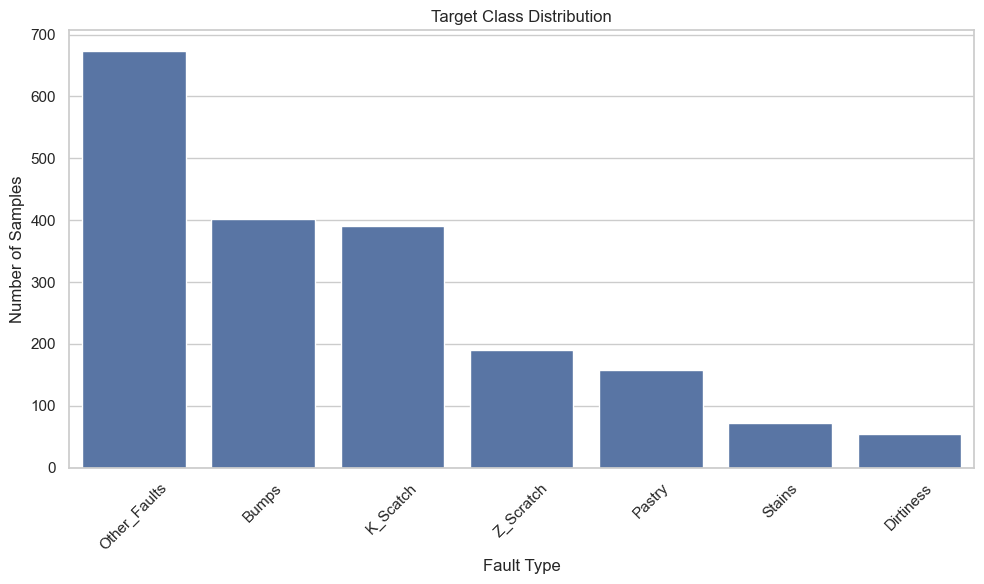

In [15]:
# Visualization

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="target",
    order=df["target"].value_counts().index
)

plt.title("Target Class Distribution")
plt.xlabel("Fault Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [16]:
# ### Observation

# The target distribution shows that the dataset contains seven
# different fault classes. The number of observations is not equal
# across all classes, with some fault types having considerably more
# samples than others.

# This class distribution is considered while evaluating the models,
# and weighted F1-score is used along with accuracy.

In [17]:
# ==============================
# NUMERICAL FEATURES
# ==============================

feature_columns = df.drop(columns=["target"]).columns

print("Number of features:", len(feature_columns))
print(feature_columns.tolist())

Number of features: 27
['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas']


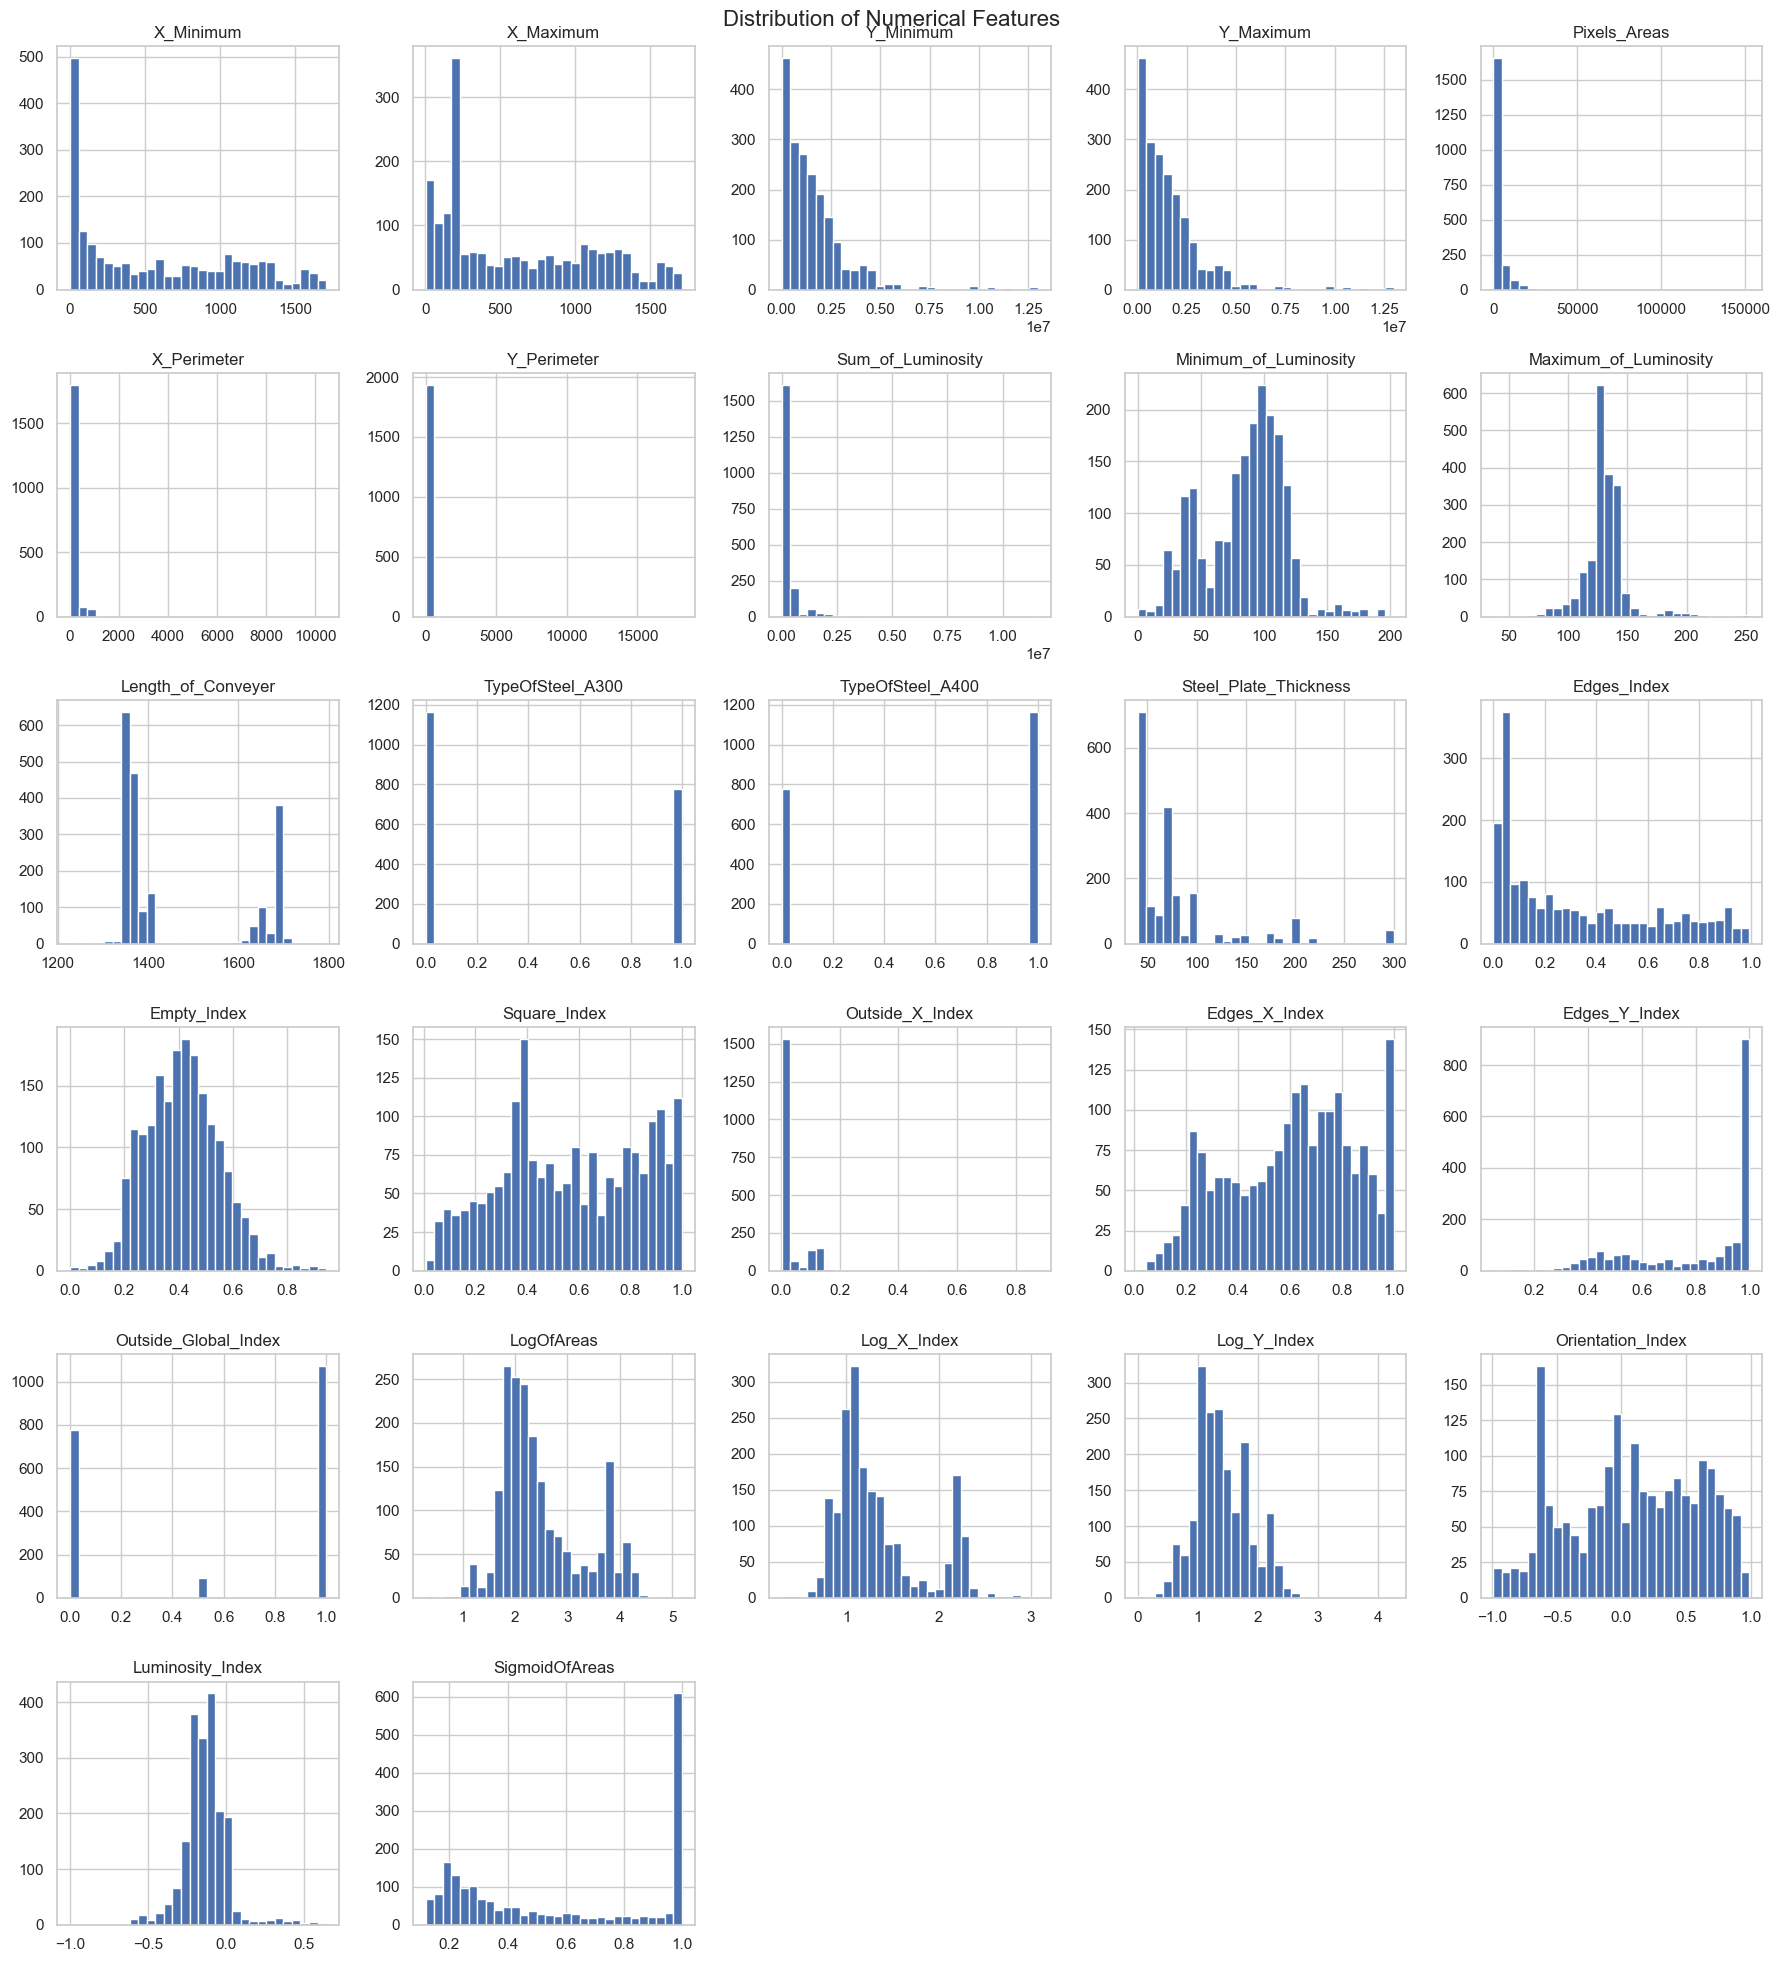

In [18]:
# ==============================
# FEATURE DISTRIBUTIONS
# ==============================

df[feature_columns].hist(
    figsize=(18, 20),
    bins=30
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

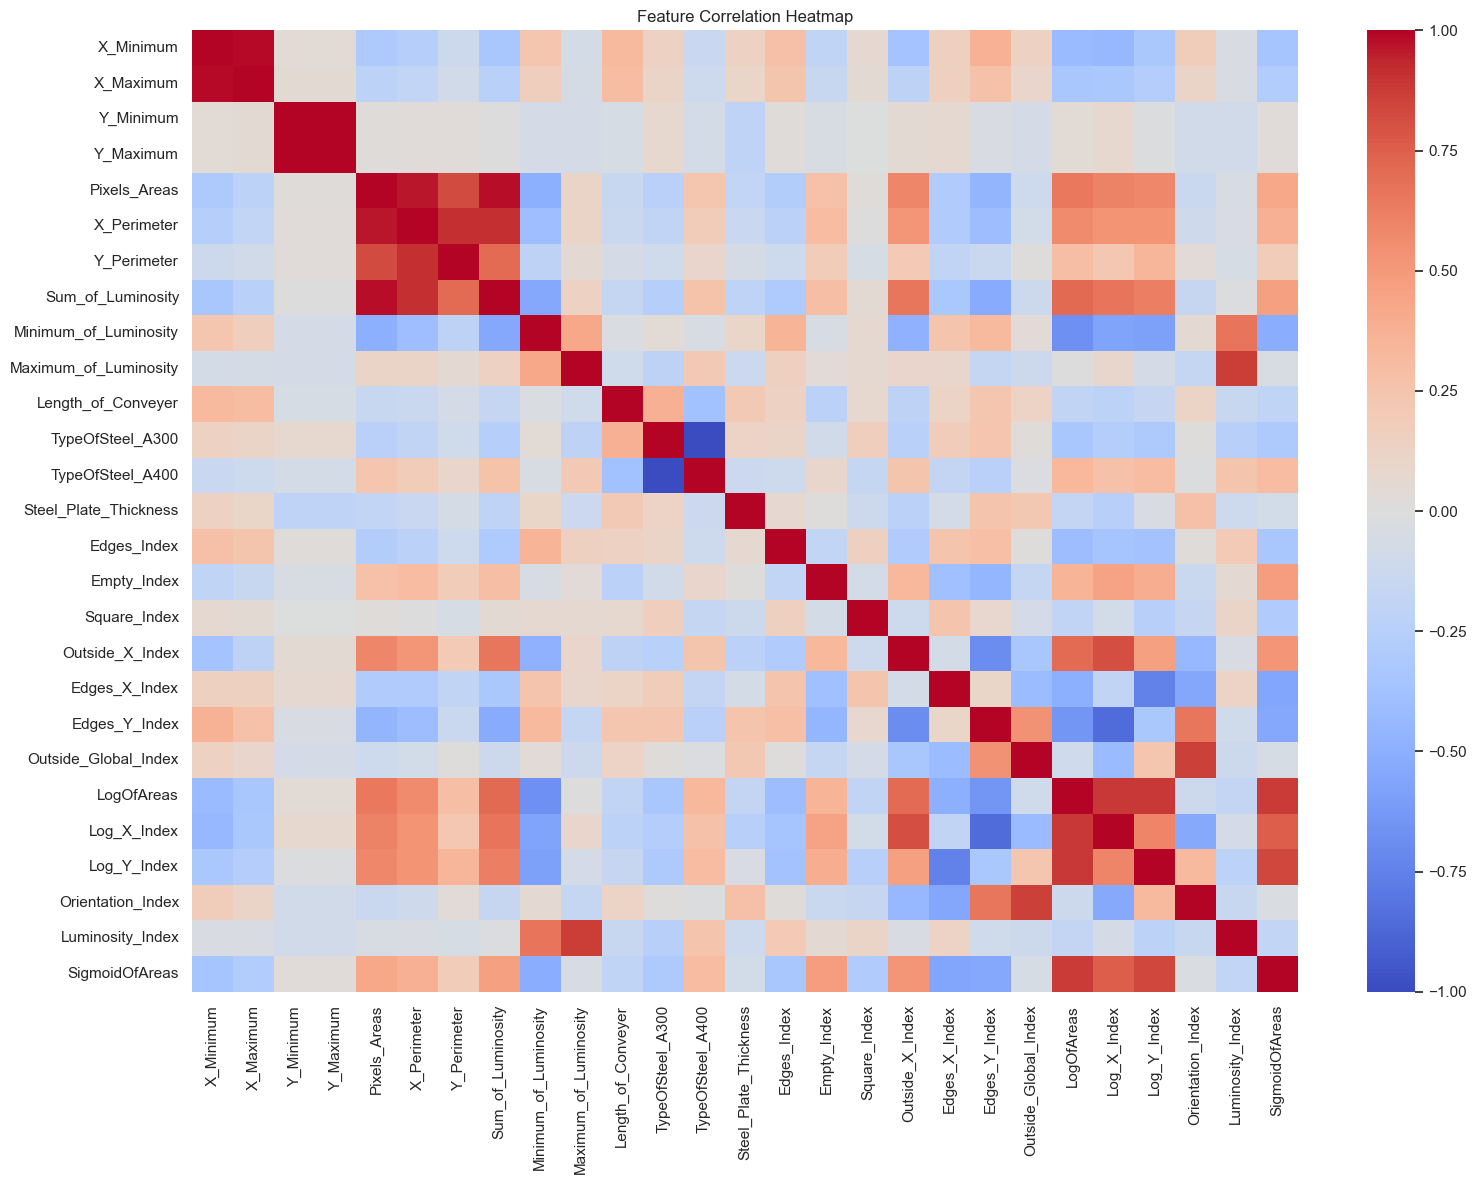

In [19]:
# ==============================
# CORRELATION HEATMAP
# ==============================

plt.figure(figsize=(16, 12))

correlation_matrix = df[feature_columns].corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [20]:
# ### Observation

# The correlation heatmap is used to identify relationships between
# the numerical features. Features with relatively high positive or
# negative correlations may contain related information, while
# features with correlations close to zero show weaker linear
# relationships.

In [21]:
# - `X_Minimum` and `X_Maximum` show a strong relationship.
# - `LogOfAreas` has a noticeable relationship with `Pixels_Areas`.
# - Some features show relatively weak linear correlation.

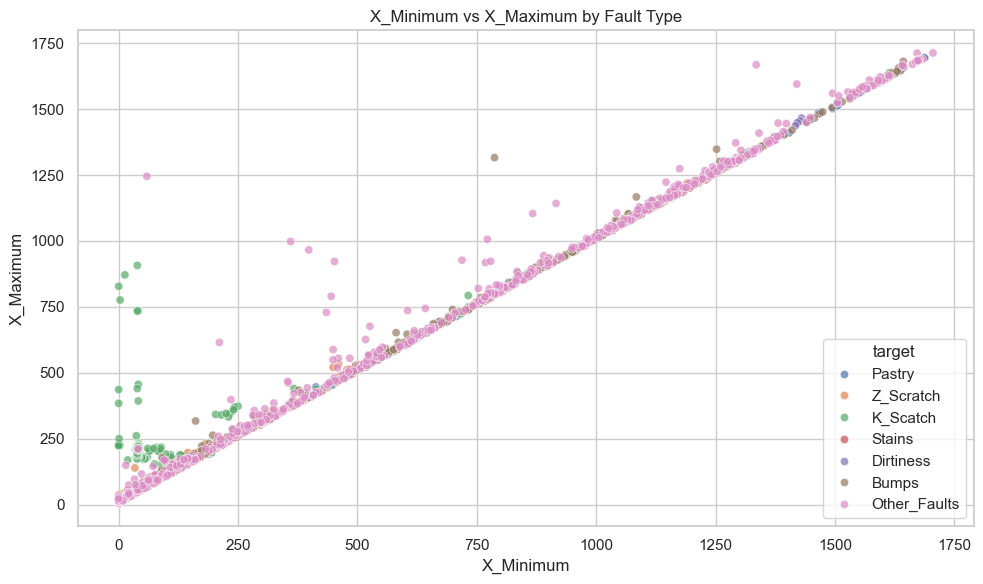

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="X_Minimum",
    y="X_Maximum",
    hue="target",
    alpha=0.7
)

plt.title("X_Minimum vs X_Maximum by Fault Type")
plt.xlabel("X_Minimum")
plt.ylabel("X_Maximum")

plt.tight_layout()
plt.show()

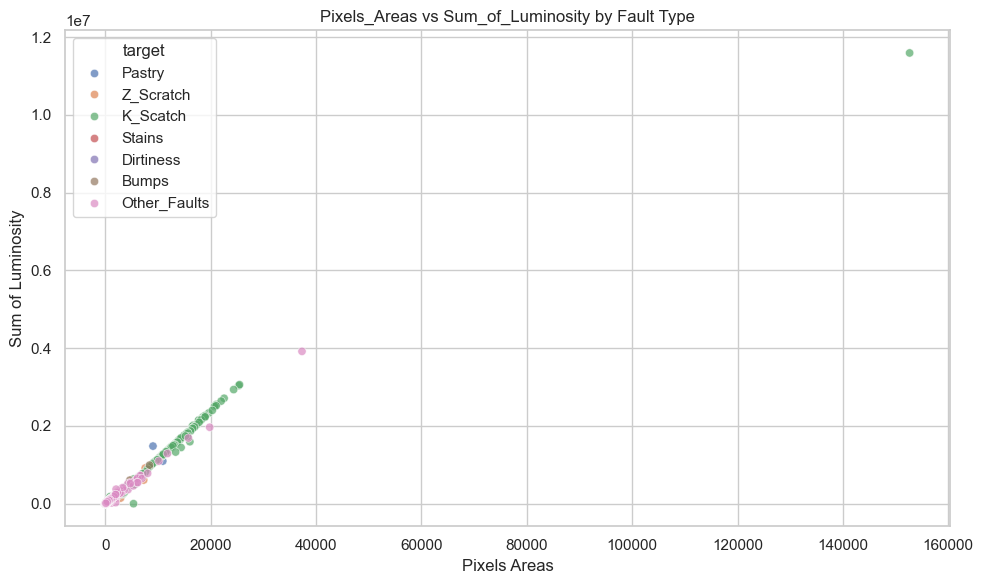

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Pixels_Areas",
    y="Sum_of_Luminosity",
    hue="target",
    alpha=0.7
)

plt.title("Pixels_Areas vs Sum_of_Luminosity by Fault Type")
plt.xlabel("Pixels Areas")
plt.ylabel("Sum of Luminosity")

plt.tight_layout()
plt.show()

In [24]:
# ### Observation

# The scatter plots provide a visual comparison of feature relationships
# across the different fault classes. Some classes show partial
# separation in feature space, while other classes overlap considerably.
# This overlap indicates why a machine learning classifier is required
# to learn nonlinear or complex decision boundaries.

In [25]:
# ==============================
# VERIFY DATA QUALITY
# ==============================

print("Total missing values:",
      df.isnull().sum().sum())

print("Total duplicate rows:",
      df.duplicated().sum())

Total missing values: 0
Total duplicate rows: 0


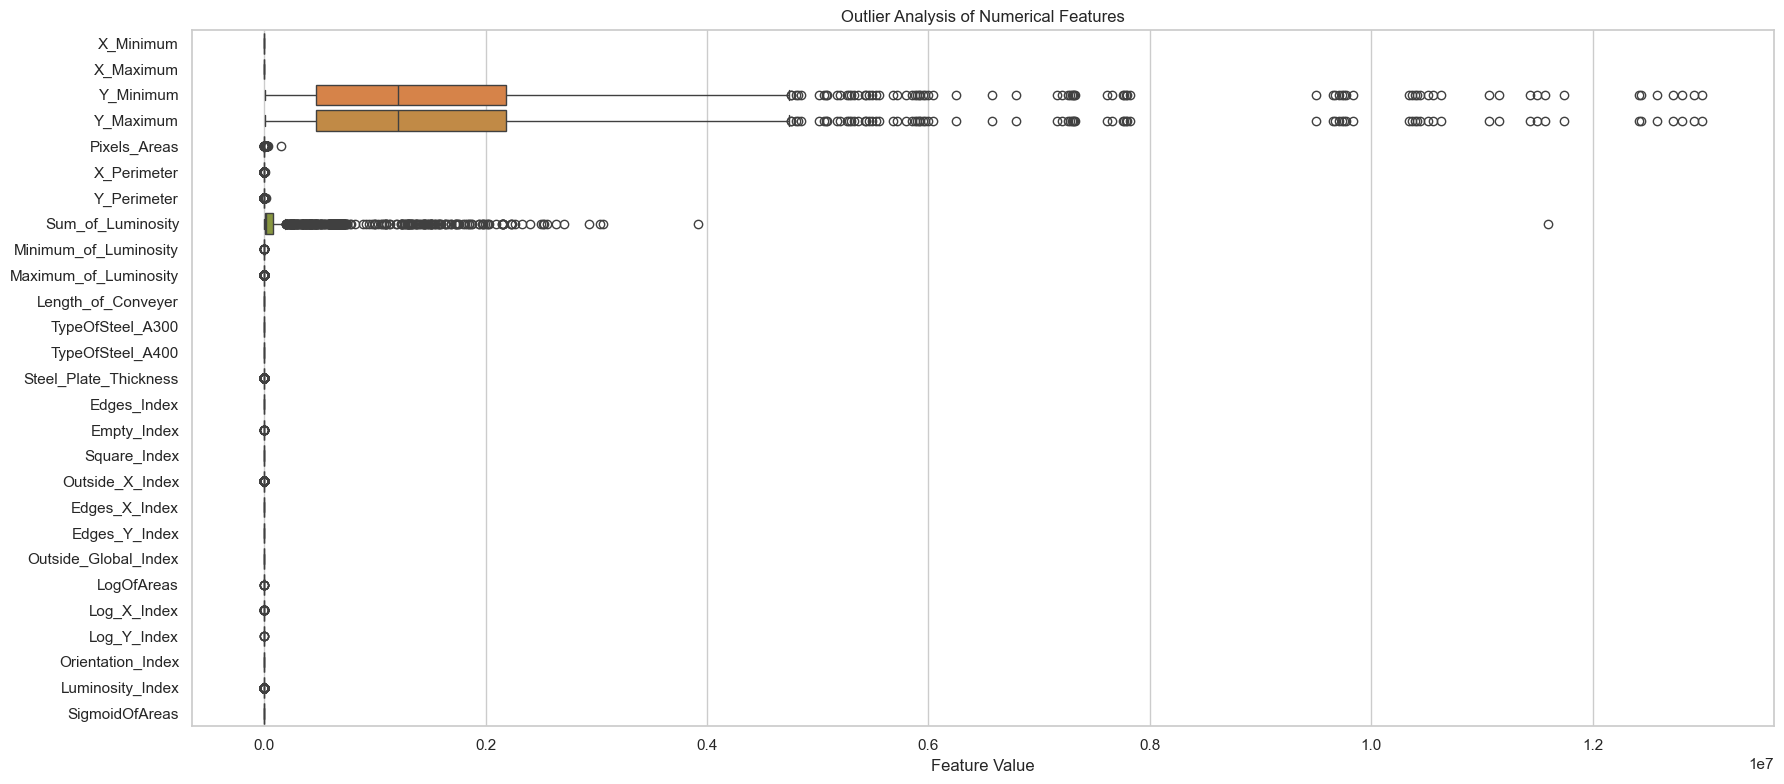

In [26]:
# ==============================
# BOXPLOT FOR FEATURE OUTLIERS
# ==============================

plt.figure(figsize=(18, 8))

sns.boxplot(
    data=df[feature_columns],
    orient="h"
)

plt.title("Outlier Analysis of Numerical Features")
plt.xlabel("Feature Value")

plt.tight_layout()
plt.show()

In [27]:
# ==============================
# IQR OUTLIER COUNTS
# ==============================

outlier_summary = {}

for column in feature_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_summary[column] = outliers

outlier_df = pd.DataFrame(
    list(outlier_summary.items()),
    columns=["Feature", "Outlier_Count"]
)

outlier_df.sort_values(
    "Outlier_Count",
    ascending=False
)

,Feature,Outlier_Count
7,Sum_of_Luminosity,399
4,Pixels_Areas,395
17,Outside_X_Index,370
5,X_Perimeter,352
13,Steel_Plate_Thickness,240
6,Y_Perimeter,179
9,Maximum_of_Luminosity,146
25,Luminosity_Index,134
3,Y_Maximum,81
2,Y_Minimum,81


In [28]:
# ==============================
# FEATURE ENGINEERING
# ==============================

df["Plate_Width"] = (
    df["X_Maximum"] - df["X_Minimum"] + 1
)

df["Plate_Height"] = (
    df["Y_Maximum"] - df["Y_Minimum"] + 1
)

df["Aspect_Ratio"] = (
    df["Plate_Width"] /
    df["Plate_Height"]
)

df[[
    "Plate_Width",
    "Plate_Height",
    "Aspect_Ratio"
]].head()

,Plate_Width,Plate_Height,Aspect_Ratio
0,9,45,0.200000
1,7,30,0.233333
2,7,19,0.368421
3,8,46,0.173913
4,18,258,0.069767


In [29]:
# ### Feature Engineering Justification

# Three geometric features were derived from the existing coordinate
# measurements:

# - `Plate_Width` represents the horizontal extent of the detected
#   region.
# - `Plate_Height` represents the vertical extent of the detected
#   region.
# - `Aspect_Ratio` represents the shape of the detected region by
#   comparing its width and height.

# These features provide the models with explicit geometric information
# that may help distinguish different types of steel plate faults.

In [30]:
# ==============================
# DEFINE FEATURES AND TARGET
# ==============================

X = df.drop(columns=["target"])
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (1941, 30)
Target shape: (1941,)


In [31]:
# ==============================
# DEFINE FEATURES AND TARGET
# ==============================

X = df.drop(columns=["target"])
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (1941, 30)
Target shape: (1941,)


In [32]:
# ## 1. Logistic Regression

# Logistic Regression is used as a baseline classification model.
# It estimates class probabilities and assigns each observation to
# a class based on the learned decision function.

In [34]:
# ==============================
# TRAIN / TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1552
Testing samples: 389


In [36]:
# ==============================
# LOGISTIC REGRESSION
# ==============================

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

y_pred_logistic = logistic_pipeline.predict(X_test)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [37]:
# ## 2. K-Nearest Neighbors

# KNN classifies an observation based on the classes of its nearest
# training observations. Feature scaling is important because KNN
# uses distance calculations.

In [38]:
# ==============================
# KNN CLASSIFIER
# ==============================

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(
        n_neighbors=5
    ))
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)

print("KNN trained successfully.")

KNN trained successfully.


In [39]:
# ## 3. Gaussian Naive Bayes

# Gaussian Naive Bayes is a probabilistic classifier based on Bayes'
# theorem. It assumes that the features are conditionally independent
# given the class.

In [40]:
# ==============================
# GAUSSIAN NAIVE BAYES
# ==============================

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Gaussian Naive Bayes trained successfully.")

Gaussian Naive Bayes trained successfully.


In [41]:
# ## 4. Decision Tree Classifier

# A Decision Tree recursively splits the feature space using feature
# thresholds to create decision rules for classification.

In [42]:
# ==============================
# DECISION TREE CLASSIFIER
# ==============================

decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

y_pred_tree = decision_tree_model.predict(X_test)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [43]:
# ## 5. Support Vector Classifier

# SVM attempts to find a decision boundary that separates classes
# while maximizing the margin between the classes. Feature scaling
# is important because SVM is sensitive to feature magnitudes.

In [44]:
# ==============================
# SUPPORT VECTOR CLASSIFIER
# ==============================

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        C=1.0,
        kernel="rbf"
    ))
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)

print("SVM trained successfully.")

SVM trained successfully.


In [45]:
# ==============================
# SUPPORT VECTOR CLASSIFIER
# ==============================

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        C=1.0,
        kernel="rbf"
    ))
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)

print("SVM trained successfully.")

SVM trained successfully.


In [48]:
# ==============================
# SVM HYPERPARAMETER TUNING
# ==============================

svm_grid = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"]
}

svm_grid_search = GridSearchCV(
    svm_pipeline,
    param_grid=svm_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

svm_grid_search.fit(X_train, y_train)

print("Best SVM parameters:")
print(svm_grid_search.best_params_)

print("\nBest CV weighted F1:")
print(svm_grid_search.best_score_)

Best SVM parameters:
{'model__C': 10, 'model__kernel': 'rbf'}

Best CV weighted F1:
0.7581286673396466


In [50]:
# ==============================
# MODEL EVALUATION FUNCTION
# ==============================

def evaluate_model(model_name, y_true, y_pred):
    
    accuracy = accuracy_score(y_true, y_pred)
    
    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Weighted F1": weighted_f1
    }

In [52]:
# ==============================
# COMPARE ALL CLASSIFIERS
# ==============================

results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_logistic
    )
)

results.append(
    evaluate_model(
        "KNN",
        y_test,
        y_pred_knn
    )
)

results.append(
    evaluate_model(
        "Gaussian Naive Bayes",
        y_test,
        y_pred_nb
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_tree
    )
)

results.append(
    evaluate_model(
        "SVM",
        y_test,
        y_pred_svm
    )
)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Weighted F1",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Weighted F1
0,SVM,0.748072,0.748953
1,Logistic Regression,0.735219,0.735113
2,KNN,0.724936,0.722118
3,Decision Tree,0.619537,0.531397
4,Gaussian Naive Bayes,0.460154,0.399748


In [53]:
# ==============================
# FORMATTED RESULTS TABLE
# ==============================

results_display = results_df.copy()

results_display["Accuracy"] = (
    results_display["Accuracy"] * 100
).round(2)

results_display["Weighted F1"] = (
    results_display["Weighted F1"]
    .round(4)
)

results_display

,Model,Accuracy,Weighted F1
0,SVM,74.81,0.7490
1,Logistic Regression,73.52,0.7351
2,KNN,72.49,0.7221
3,Decision Tree,61.95,0.5314
4,Gaussian Naive Bayes,46.02,0.3997


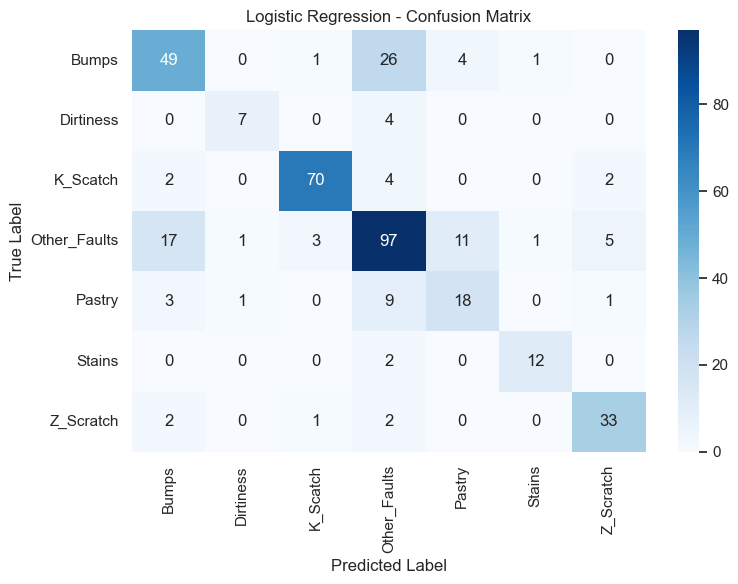

In [54]:
# ==============================
# CONFUSION MATRIX:
# LOGISTIC REGRESSION
# ==============================

cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

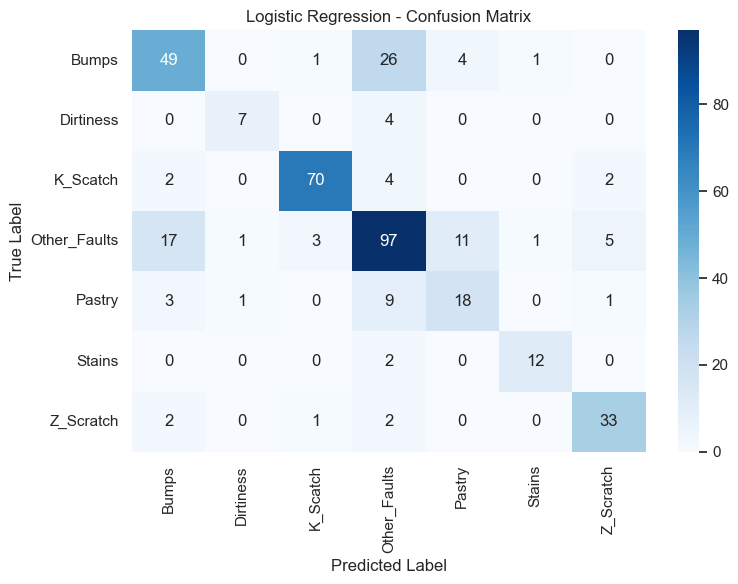

In [55]:
# ==============================
# CONFUSION MATRIX:
# LOGISTIC REGRESSION
# ==============================

cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

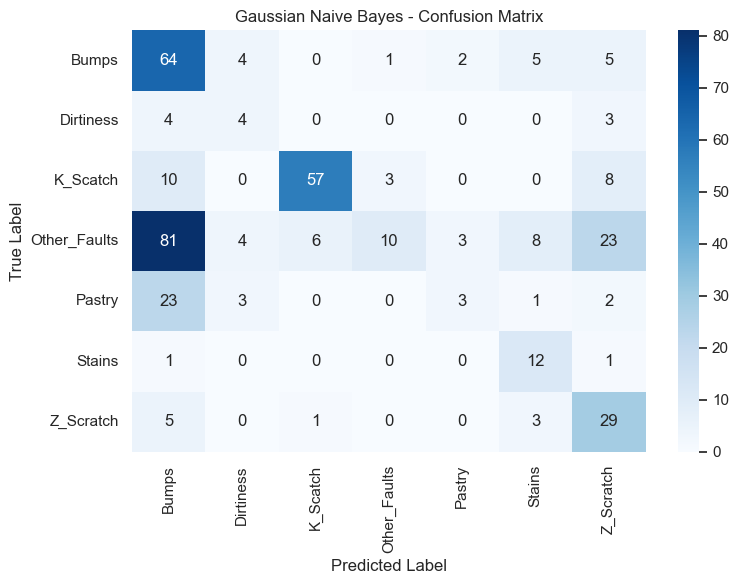

In [56]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

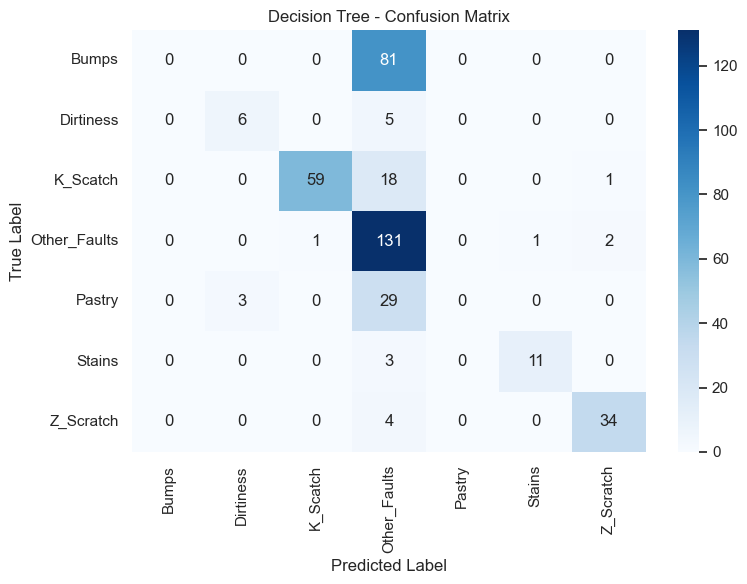

In [57]:
cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

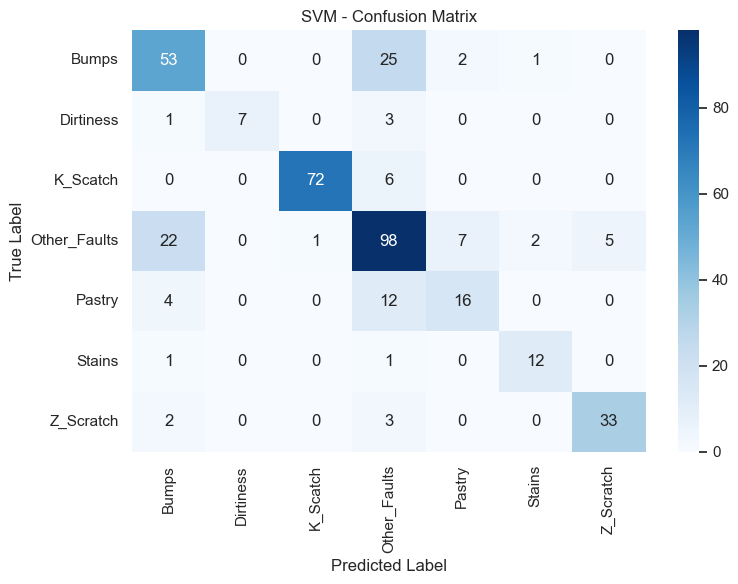

In [58]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [59]:
# ==============================
# CLASSIFICATION REPORTS
# ==============================

model_predictions = {
    "Logistic Regression": y_pred_logistic,
    "KNN": y_pred_knn,
    "Gaussian Naive Bayes": y_pred_nb,
    "Decision Tree": y_pred_tree,
    "SVM": y_pred_svm
}

for model_name, predictions in model_predictions.items():
    
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    
    print(
        classification_report(
            y_test,
            predictions
        )
    )

Logistic Regression
              precision    recall  f1-score   support

       Bumps       0.67      0.60      0.64        81
   Dirtiness       0.78      0.64      0.70        11
    K_Scatch       0.93      0.90      0.92        78
Other_Faults       0.67      0.72      0.70       135
      Pastry       0.55      0.56      0.55        32
      Stains       0.86      0.86      0.86        14
   Z_Scratch       0.80      0.87      0.84        38

    accuracy                           0.74       389
   macro avg       0.75      0.74      0.74       389
weighted avg       0.74      0.74      0.74       389

KNN
              precision    recall  f1-score   support

       Bumps       0.56      0.74      0.63        81
   Dirtiness       0.89      0.73      0.80        11
    K_Scatch       0.96      0.95      0.95        78
Other_Faults       0.71      0.61      0.65       135
      Pastry       0.57      0.38      0.45        32
      Stains       0.75      0.86      0.80        14


In [60]:
# # Classification Results — Review 1

# Five Classification Part-A algorithms were implemented:

# 1. Logistic Regression
# 2. K-Nearest Neighbors
# 3. Gaussian Naive Bayes
# 4. Decision Tree Classifier
# 5. Support Vector Classifier

# The models were evaluated using the same stratified train/test split.

# The primary evaluation metrics used for Review 1 were:

# - Accuracy
# - Weighted F1-score
# - Confusion Matrix

In [61]:
results_df

,Model,Accuracy,Weighted F1
0,SVM,0.748072,0.748953
1,Logistic Regression,0.735219,0.735113
2,KNN,0.724936,0.722118
3,Decision Tree,0.619537,0.531397
4,Gaussian Naive Bayes,0.460154,0.399748


In [62]:
# ## Final Observations

# The five classification algorithms produced different levels of
# performance on the steel plate fault classification task.

# Based on the test-set results, the models differ in both accuracy
# and weighted F1-score. The confusion matrices also show which fault
# classes are easier or more difficult for the classifiers to
# distinguish.

# The final interpretation is based on the observed test-set metrics
# and class-wise prediction behaviour.

In [63]:
# Among the evaluated models, SVM achieved the highest weighted
# F1-score on the test set. However, the confusion matrix shows
# that some minority classes remain more difficult to classify.